<a href="https://colab.research.google.com/github/qvalen/Safari-City---Games-Analysis/blob/main/Maliyo_SafariCity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Step 1: Read the Excel file
df = pd.read_excel('Firebase_overview.xlsx', header=2)  # Change 2 if headers are on a different row

# Step 2: Save as CSV
df.to_csv('Firebase_overview.csv', index=False)

print("✅ Conversion complete! CSV file saved as Firebase_overview.csv")

✅ Conversion complete! CSV file saved as Firebase_overview.csv


In [ ]:
# Load the new CSV
df = pd.read_csv('Firebase_overview.csv')

# Preview first 5 rows
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,# How are active users trending?,NaN,NaN,NaN,NaN,NaN,NaN
1,# Start date: 20250801,NaN,NaN,NaN,NaN,NaN,NaN
2,# End date: 20250831,NaN,NaN,NaN,NaN,NaN,NaN
3,Nth day,30 days,7 days,1 day,NaN,NaN,NaN
4,0,21818,9009,2109,NaN,NaN,NaN


In [ ]:
# Remove completely empty columns
df = df.dropna(axis=1, how='all')

# Remove completely empty rows
df = df.dropna(axis=0, how='all')

# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Check cleaned columns and first 5 rows
df.head()
df.columns

Index(['# ----------------------------------------', 'Unnamed: 1',
       'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6'],
      dtype='object')

In [ ]:
import pandas as pd

# Step 1: Load the file, skipping the first 4 irrelevant rows
df = pd.read_csv('Firebase_overview.csv', skiprows=4)

# Step 2: Drop the last 3 empty columns
df = df.iloc[:, :4]

# Step 3: Rename the 4 columns clearly
df.columns = ['Nth day', '30 days', '7 days', '1 day']

# Step 4: Check the first few rows
df.head(10)

,Nth day,30 days,7 days,1 day
0,0,21818,9009,2109
1,1,22539,9068,2178
2,2,23237,9213,2177
3,3,23760,9462,2022
4,4,24392,9597,1976
5,5,24987,9600,1975
6,6,25563,9672,1967
7,7,26101,9728,2089
8,8,26571,9828,2211
9,9,27040,9841,2159


In [ ]:
# Check data types and missing values
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2889 entries, 0 to 2888
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Nth day  2872 non-null   object
 1   30 days  2829 non-null   object
 2   7 days   73 non-null     object
 3   1 day    70 non-null     object
dtypes: object(4)
memory usage: 90.4+ KB


,Nth day,30 days,7 days,1 day
count,2872,2829,73,70
unique,2666,425,72,68
top,# End date: 20250831,1,Successful,-1
freq,14,958,2,2


In [ ]:
# Step 1: Remove rows where 'Nth day' is NaN
df = df[df['Nth day'].notna()]

# Step 2: Keep only rows where 'Nth day' contains digits
df = df[df['Nth day'].astype(str).str.isnumeric()]

# Step 3: Convert all columns to numeric (coerce errors to NaN)
df = df.apply(pd.to_numeric, errors='coerce')

# Step 4: Drop rows where all values are NaN (cleanup)
df = df.dropna(how='all')

# Preview the cleaned data
df.head()

,Nth day,30 days,7 days,1 day
0,0,21818.0,9009.0,2109.0
1,1,22539.0,9068.0,2178.0
2,2,23237.0,9213.0,2177.0
3,3,23760.0,9462.0,2022.0
4,4,24392.0,9597.0,1976.0


In [ ]:
# Confirm the data types
df.info()

# Quick statistical summary
df.describe()

# View first few rows neatly
print(df.head(10).to_string(index=False))

<class 'pandas.core.frame.DataFrame'>
Index: 228 entries, 0 to 2059
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Nth day  228 non-null    int64  
 1   30 days  226 non-null    float64
 2   7 days   62 non-null     float64
 3   1 day    62 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 8.9 KB
 Nth day  30 days  7 days  1 day
       0  21818.0  9009.0 2109.0
       1  22539.0  9068.0 2178.0
       2  23237.0  9213.0 2177.0
       3  23760.0  9462.0 2022.0
       4  24392.0  9597.0 1976.0
       5  24987.0  9600.0 1975.0
       6  25563.0  9672.0 1967.0
       7  26101.0  9728.0 2089.0
       8  26571.0  9828.0 2211.0
       9  27040.0  9841.0 2159.0


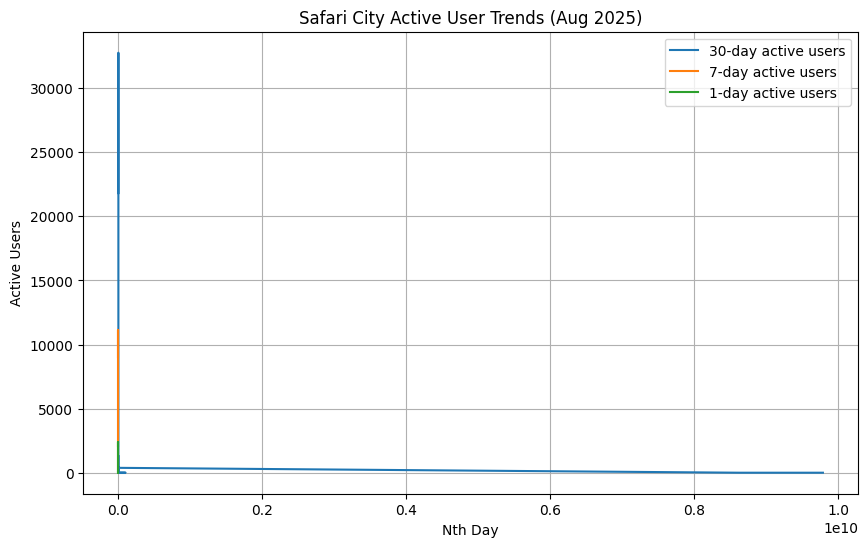

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df['Nth day'], df['30 days'], label='30-day active users')
plt.plot(df['Nth day'], df['7 days'], label='7-day active users')
plt.plot(df['Nth day'], df['1 day'], label='1-day active users')
plt.title('Safari City Active User Trends (Aug 2025)')
plt.xlabel('Nth Day')
plt.ylabel('Active Users')
plt.legend()
plt.grid(True)
plt.show()

Data Analysis & Recommendations

Visualization of Early Player Funnel:

The chart above visualizes player engagement for Safari City across 30-day, 7-day, and 1-day active users in August 2025. The data shows a sharp decline in engagement after the first few days, with the 30-day active users maintaining a gradual presence compared to the 7-day and 1-day groups.

Key Insights:

1. Player activity peaks early but drops significantly after the first few sessions.

2. Most players do not continue playing beyond the first week.

3. A smaller, consistent group of loyal users stays active across the 30-day period.

4. Despite the existence of a streak reward system, many players still disengage early, suggesting that current incentives may not be compelling enough to encourage continuous play.

Recommendations:

1. Enhance the streak reward system: Instead of static streak bonuses, introduce dynamic or escalating rewards (e.g., rare items, bonus levels, or visual badges) that increase with longer streaks.

2. Add milestone rewards: Give players a sense of progress by rewarding them after completing key milestones (like finishing a level set or unlocking new regions).

3. Improve early gameplay experience: Focus on smoother tutorials, faster rewards, and immediate excitement within the first few levels to hook new users.

4. Introduce event-based missions: Limited-time challenges or weekend events could motivate returning players to log in more often.

5. Personalized re-engagement: Use push notifications or emails that reflect the player’s last progress (e.g., “Your city is waiting for you!” or “Continue your streak to unlock a special gift!”).

6. Analyze loyal users: Examine what keeps 30-day users active and replicate those experiences for newer players.